In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(handle_unknown='ignore')
import warnings
warnings.filterwarnings("ignore")

# pd.set_option("display.width", 150) 
# pd.set_option("display.precision", 3)
# plt.rcParams["figure.figsize"] = (9, 4.2)
# plt.rcParams["axes.grid"] = True
# plt.rcParams["grid.alpha"] = 0.3
# plt.rcParams["figure.dpi"] = 110

SEED = 42

In [114]:
df = pd.read_csv("data/online_shoppers_intention.csv")
df.head(10)

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.0,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.0,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.0,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
5,0,0.0,0,0.0,19,154.216667,0.015789,0.024561,0.0,0.0,Feb,2,2,1,3,Returning_Visitor,False,False
6,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.0,0.4,Feb,2,4,3,3,Returning_Visitor,False,False
7,1,0.0,0,0.0,0,0.000000,0.200000,0.200000,0.0,0.0,Feb,1,2,1,5,Returning_Visitor,True,False
8,0,0.0,0,0.0,2,37.000000,0.000000,0.100000,0.0,0.8,Feb,2,2,2,3,Returning_Visitor,False,False
9,0,0.0,0,0.0,3,738.000000,0.000000,0.022222,0.0,0.4,Feb,2,4,1,2,Returning_Visitor,False,False


In [50]:
df.shape

(12330, 18)

# EDA

In [8]:
print('Все колонки:', df.columns.tolist())
df.info()

Все колонки: ['Administrative', 'Administrative_Duration', 'Informational', 'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration', 'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month', 'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType', 'Weekend', 'Revenue']
<class 'pandas.DataFrame'>
RangeIndex: 12330 entries, 0 to 12329
Data columns (total 18 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Administrative           12330 non-null  int64  
 1   Administrative_Duration  12330 non-null  float64
 2   Informational            12330 non-null  int64  
 3   Informational_Duration   12330 non-null  float64
 4   ProductRelated           12330 non-null  int64  
 5   ProductRelated_Duration  12330 non-null  float64
 6   BounceRates              12330 non-null  float64
 7   ExitRates                12330 non-null  float64
 8   PageValues               12330 non-null  float64
 9 

In [115]:
df[['Revenue', 'Weekend']] = df[['Revenue', 'Weekend']].astype(int)

In [116]:
df.isnull().sum()

Administrative             0
Administrative_Duration    0
Informational              0
Informational_Duration     0
ProductRelated             0
ProductRelated_Duration    0
BounceRates                0
ExitRates                  0
PageValues                 0
SpecialDay                 0
Month                      0
OperatingSystems           0
Browser                    0
Region                     0
TrafficType                0
VisitorType                0
Weekend                    0
Revenue                    0
dtype: int64

In [117]:
target_feature = 'Revenue'
categ_features = {'Month', 'Weekend', 'VisitorType', 'TrafficType', 'Region', 'Browser', 'OperatingSystems'}
quant_features = set(df.select_dtypes(include=np.number).columns.to_list()) - categ_features


In [118]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
missing_pct = (missing / len(df)) * 100

missing_df = pd.DataFrame({
    'Кол-во пропусков': missing,
    'Процент': missing_pct
})
print(missing_df)

Empty DataFrame
Columns: [Кол-во пропусков, Процент]
Index: []


In [119]:
total_duplicates = df.duplicated().sum()
print(f"Всего дублирующихся строк: {total_duplicates}")

Всего дублирующихся строк: 125


In [120]:
df.drop_duplicates(inplace=True)

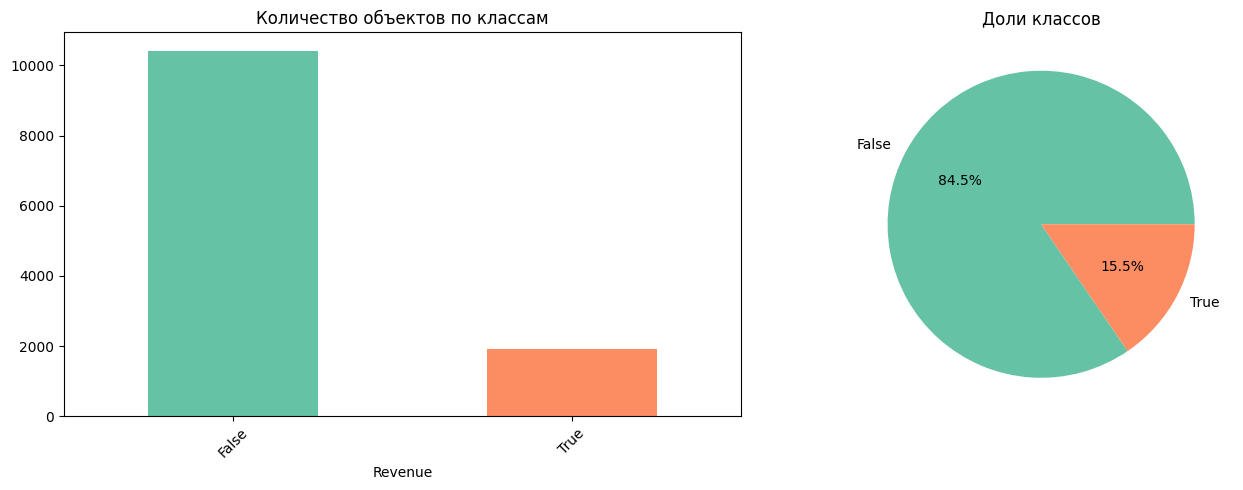

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df[target_feature].value_counts().plot.bar(ax=axes[0], color=sns.color_palette('Set2'))
axes[0].set_title('Количество объектов по классам')
axes[0].tick_params(axis='x', rotation=45)

df[target_feature].value_counts(normalize=True).plot.pie(ax=axes[1], autopct='%1.1f%%', colors=sns.color_palette('Set2'))
axes[1].set_ylabel('')
axes[1].set_title('Доли классов')
plt.tight_layout()
plt.show()

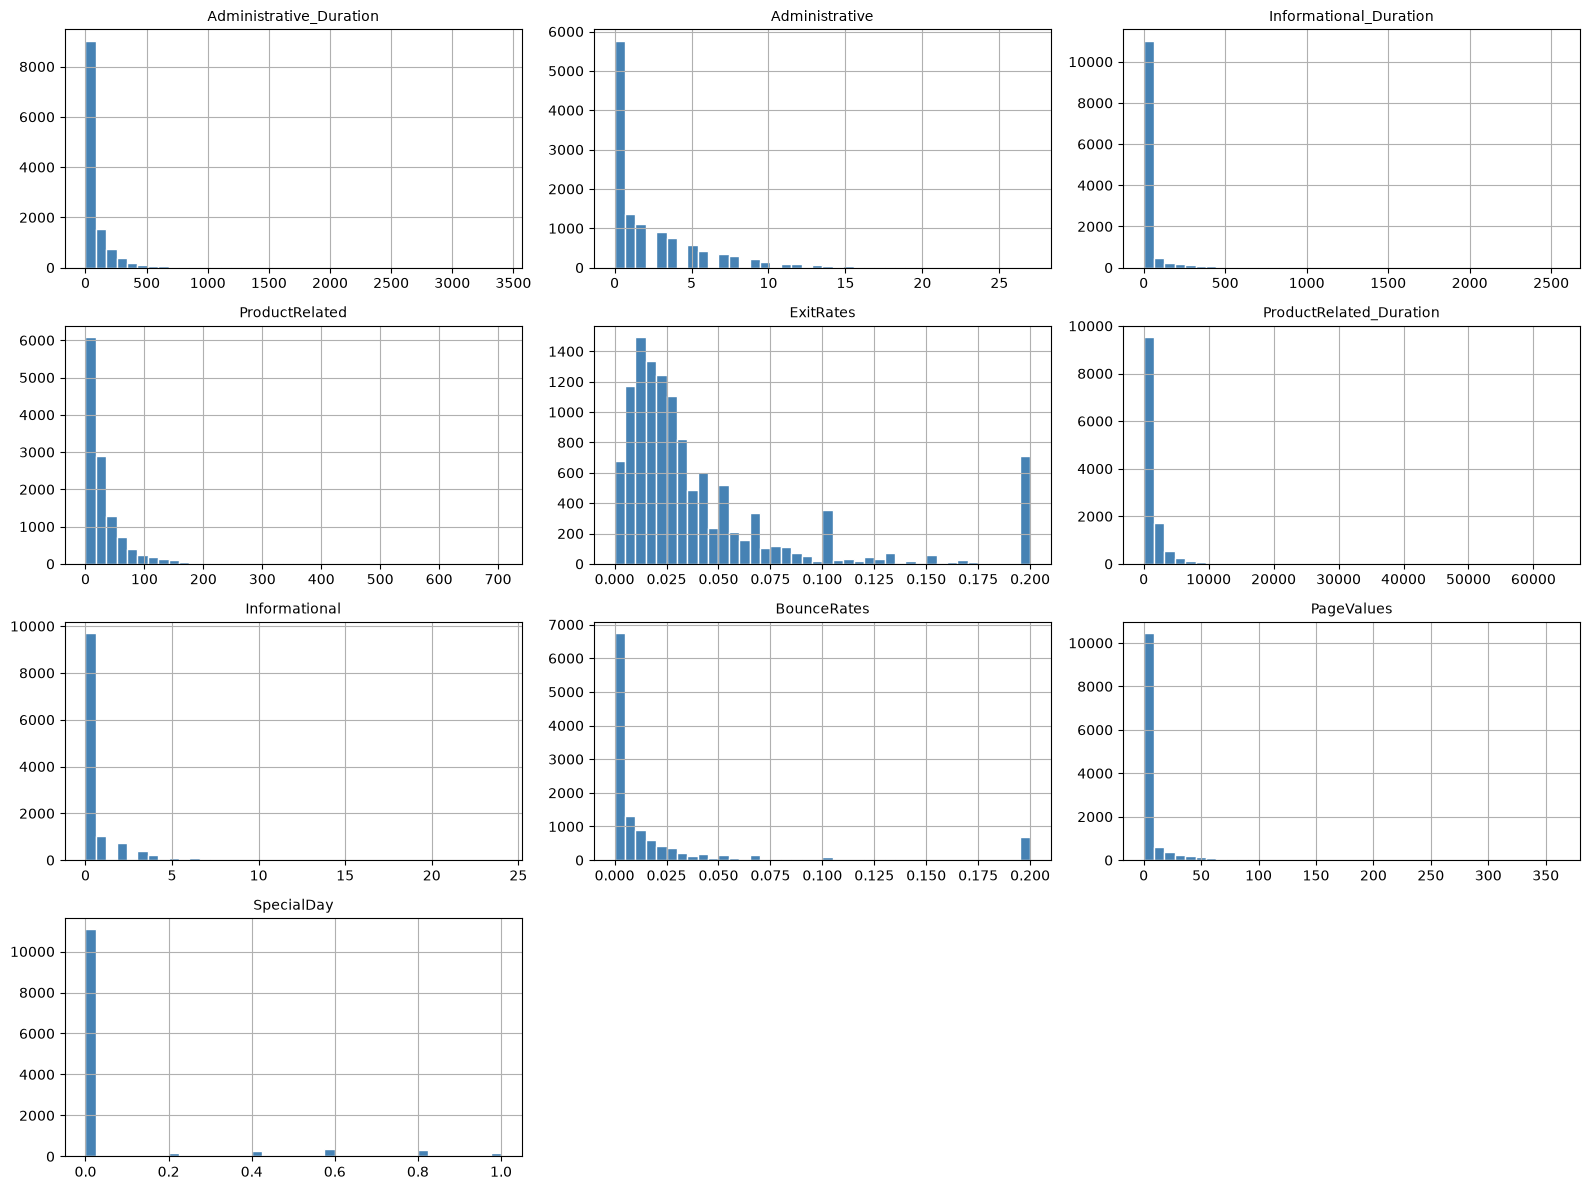

In [12]:
n_cols = len(quant_features)
n_rows = (n_cols + 2) // 3
fig, axes = plt.subplots(n_rows, 3, figsize=(16, n_rows * 3))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    df[col].hist(bins=40, ax=axes[i], color='steelblue', edgecolor='white')
    axes[i].set_title(col, fontsize=10)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df[list(quant_features)].describe(percentiles=[.05, .25, .50, .75, .95, .99]).T


,count,mean,std,min,5%,25%,50%,75%,95%,99%,max
BounceRates,12330.0,0.022191,0.048488,0.0,0.000000,0.000000,0.003112,0.016813,0.200000,0.200000,0.200000
Informational,12330.0,0.503569,1.270156,0.0,0.000000,0.000000,0.000000,0.000000,3.000000,6.000000,24.000000
ProductRelated_Duration,12330.0,1194.746220,1913.669288,0.0,0.000000,184.137500,598.936905,1464.157214,4300.289077,8701.142697,63973.522230
ExitRates,12330.0,0.043073,0.048597,0.0,0.004568,0.014286,0.025156,0.050000,0.200000,0.200000,0.200000
ProductRelated,12330.0,31.731468,44.475503,0.0,1.000000,7.000000,18.000000,38.000000,109.000000,221.000000,705.000000
SpecialDay,12330.0,0.061427,0.198917,0.0,0.000000,0.000000,0.000000,0.000000,0.600000,1.000000,1.000000
Administrative,12330.0,2.315166,3.321784,0.0,0.000000,0.000000,1.000000,4.000000,9.000000,14.000000,27.000000
Administrative_Duration,12330.0,80.818611,176.779107,0.0,0.000000,0.000000,7.500000,93.256250,348.266369,830.587041,3398.750000
Informational_Duration,12330.0,34.472398,140.749294,0.0,0.000000,0.000000,0.000000,0.000000,195.000000,716.390000,2549.375000
PageValues,12330.0,5.889258,18.568437,0.0,0.000000,0.000000,0.000000,0.000000,38.160528,85.498490,361.763742


## Логарифмирование

<Axes: >

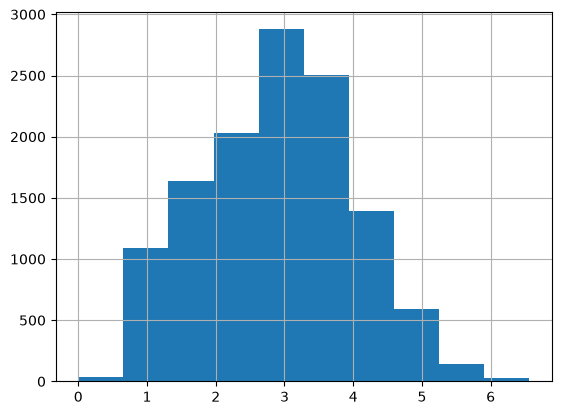

In [13]:
df['ProductRelated_log'] = np.log1p(df['ProductRelated'])
df['ProductRelated_log'].hist()

In [5]:
sns.boxplot(x=target_feature, y='ProductRelated_log', data=df)

ValueError: Could not interpret value `ProductRelated_log` for `y`. An entry with this name does not appear in `data`.

<Axes: >

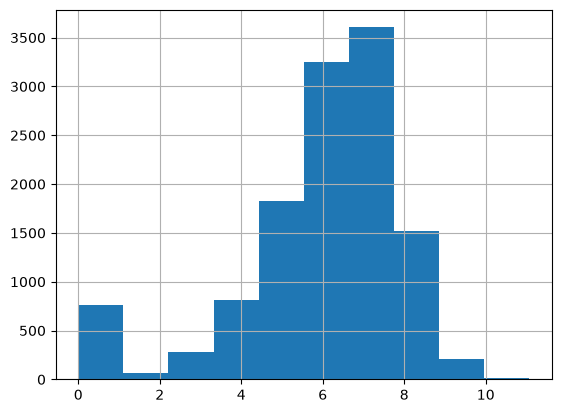

In [15]:
df['ProductRelated_Duration_log'] = np.log1p(df['ProductRelated_Duration'])
df['ProductRelated_Duration_log'].hist()

<Axes: >

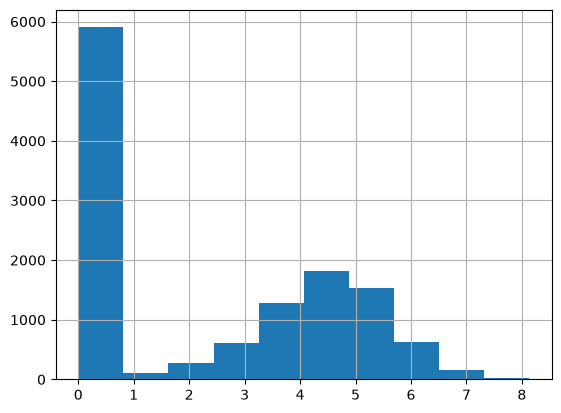

In [16]:
df['Administrative_Duration_log'] = np.log1p(df['Administrative_Duration'])
df['Administrative_Duration_log'].hist()

<Axes: xlabel='Revenue', ylabel='Administrative_Duration_log'>

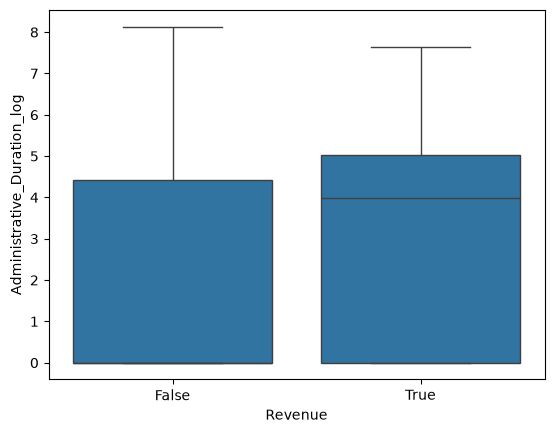

In [17]:
sns.boxplot(x=target_feature, y='Administrative_Duration_log', data=df)

<Axes: >

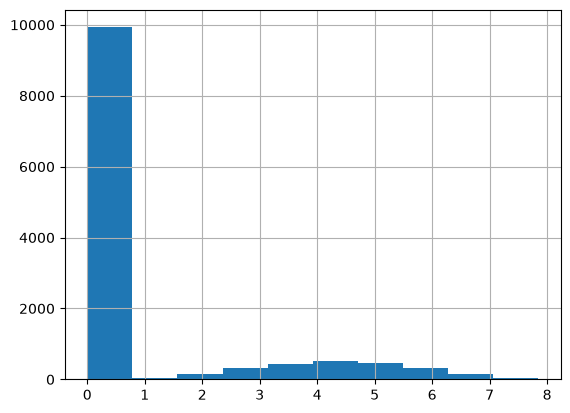

In [18]:
df['Informational_Duration_log'] = np.log1p(df['Informational_Duration'])
df['Informational_Duration_log'].hist()

<Axes: xlabel='Revenue', ylabel='Informational_Duration_log'>

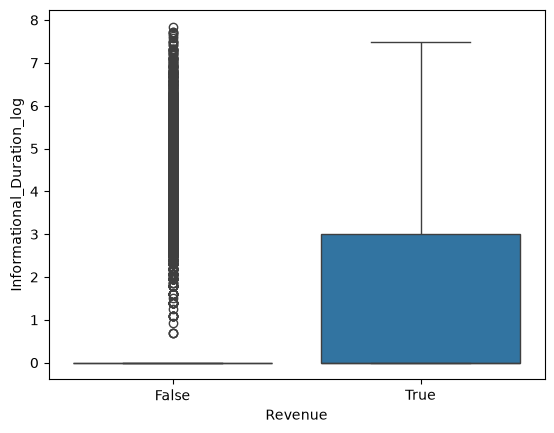

In [19]:
sns.boxplot(x=target_feature, y='Informational_Duration_log', data=df)

<Axes: >

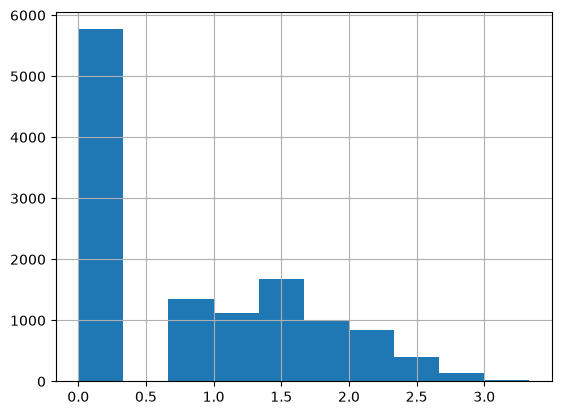

In [20]:
df['Administrative_log'] = np.log1p(df['Administrative'])
df['Administrative_log'].hist()

<Axes: xlabel='Revenue', ylabel='Administrative_log'>

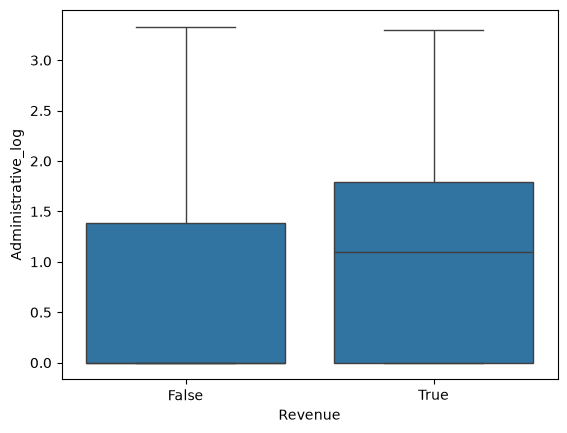

In [21]:
sns.boxplot(x=target_feature, y='Administrative_log', data=df)

<Axes: >

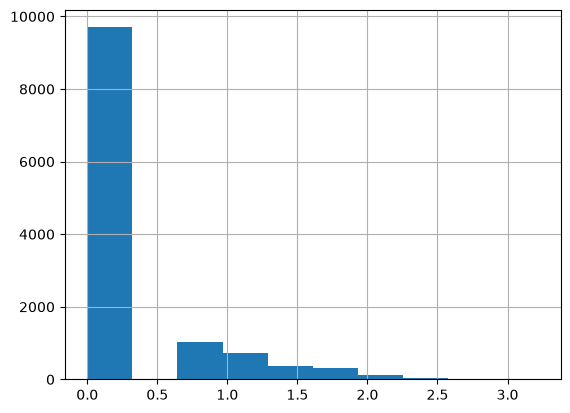

In [22]:
df['Informational_log'] = np.log1p(df['Informational'])
df['Informational_log'].hist()

<Axes: xlabel='Revenue', ylabel='Informational_log'>

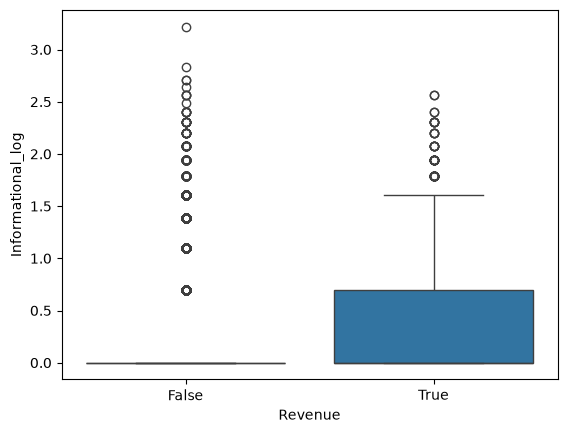

In [23]:
sns.boxplot(x=target_feature, y='Informational_log', data=df)

<Axes: xlabel='Revenue', ylabel='PageValues_log'>

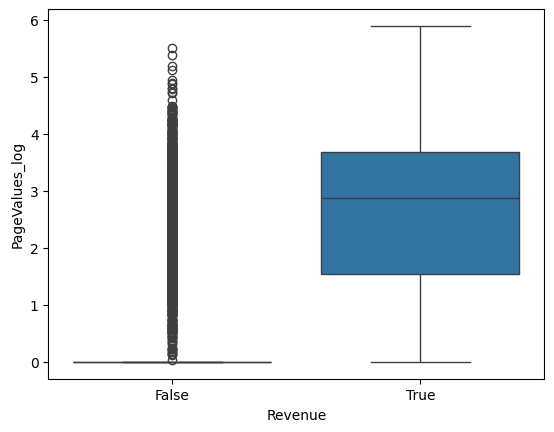

In [ ]:
df['PageValues_log'] = np.log1p(df['PageValues'])

sns.boxplot(
    data=df,
    x=target_feature,
    y='PageValues_log'
)

<Axes: >

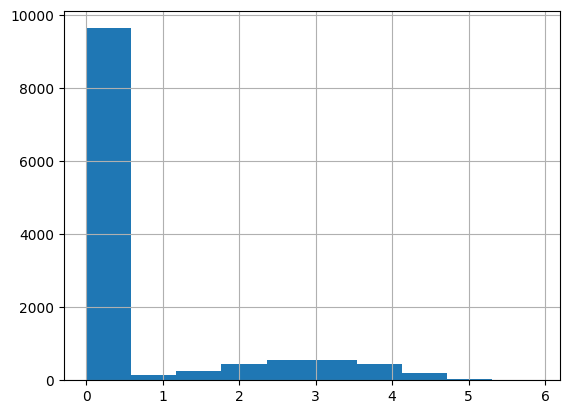

In [ ]:
df['PageValues_log'].hist()

## Категориальные фичи

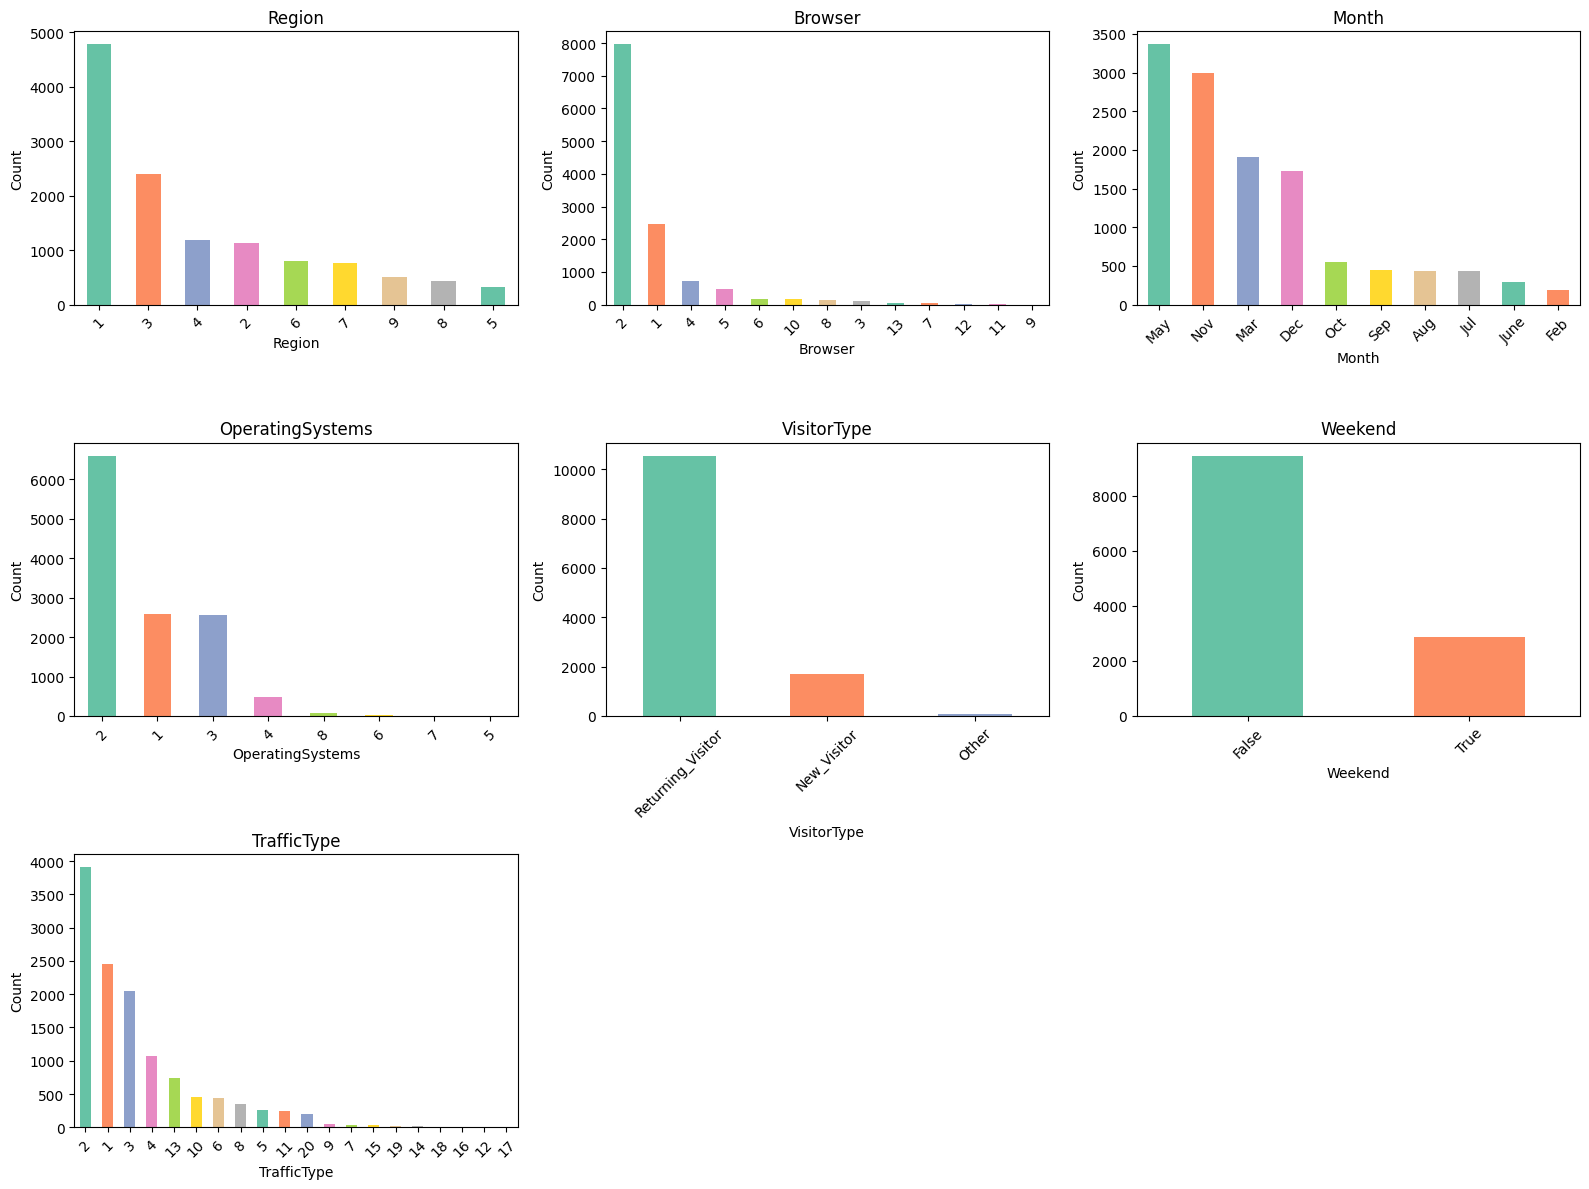

In [ ]:
n_cols = 3
n_rows = (len(categ_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, n_rows * 4))
axes = axes.flatten()

for i, col in enumerate(categ_features):
    df[col].value_counts().plot.bar(ax=axes[i], color=sns.color_palette('Set2'))
    axes[i].set_title(col, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_ylabel('Count')

for j in range(len(categ_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

In [ ]:
df['Browser'].value_counts()

,count
Browser,
2,7961
1,2462
4,736
5,467
6,174
10,163
8,135
3,105
13,61


In [ ]:
df['OperatingSystems'].value_counts()

,count
OperatingSystems,
2,6601
1,2585
3,2555
4,478
8,79
6,19
7,7
5,6


In [8]:
df['TrafficType'].value_counts()

TrafficType
2     3913
1     2451
3     2052
4     1069
13     738
10     450
6      444
8      343
5      260
11     247
20     198
9       42
7       40
15      38
19      17
14      13
18      10
16       3
12       1
17       1
Name: count, dtype: int64

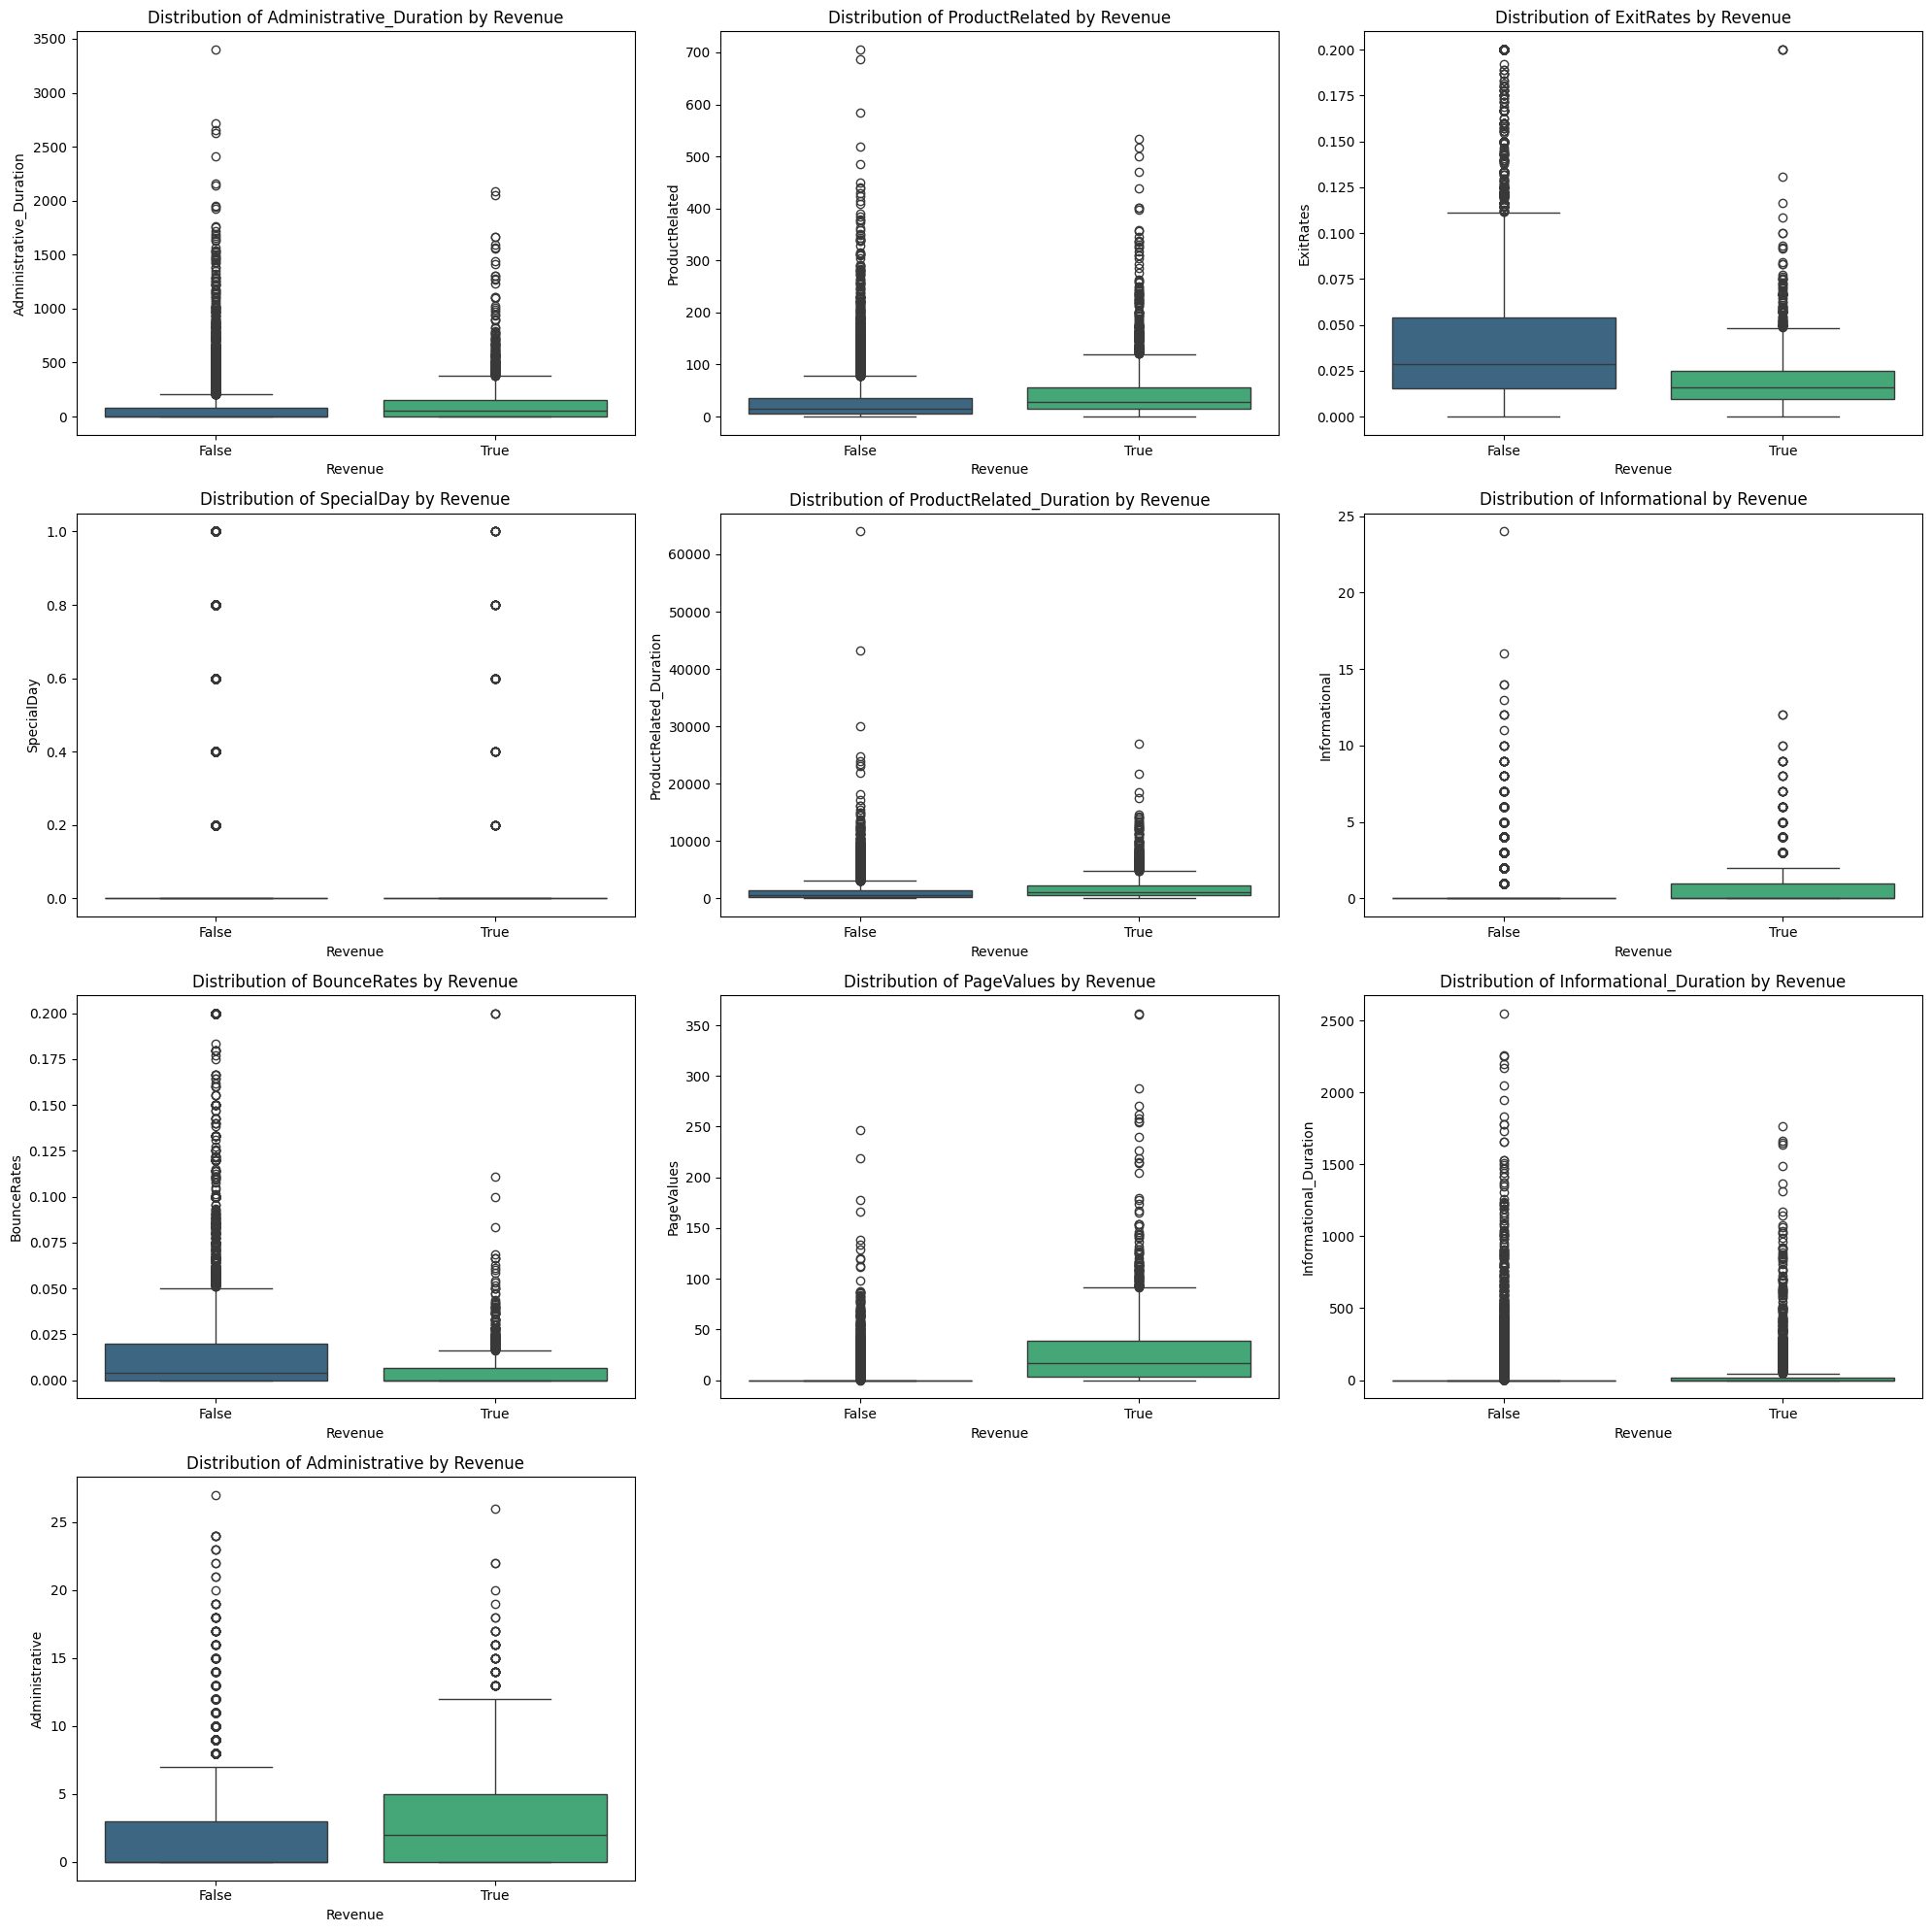

In [ ]:
n_cols = 3
n_rows = (len(quant_features) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 5))
axes = axes.flatten()

for i, col in enumerate(quant_features):
    sns.boxplot(x=target_feature, y=col, data=df, ax=axes[i], palette='viridis')
    axes[i].set_title(f'Distribution of {col} by {target_feature}', fontsize=12)
    axes[i].set_xlabel(target_feature)
    axes[i].set_ylabel(col)

for j in range(len(quant_features), len(axes)):
    axes[j].set_visible(False)

plt.tight_layout()
plt.show()

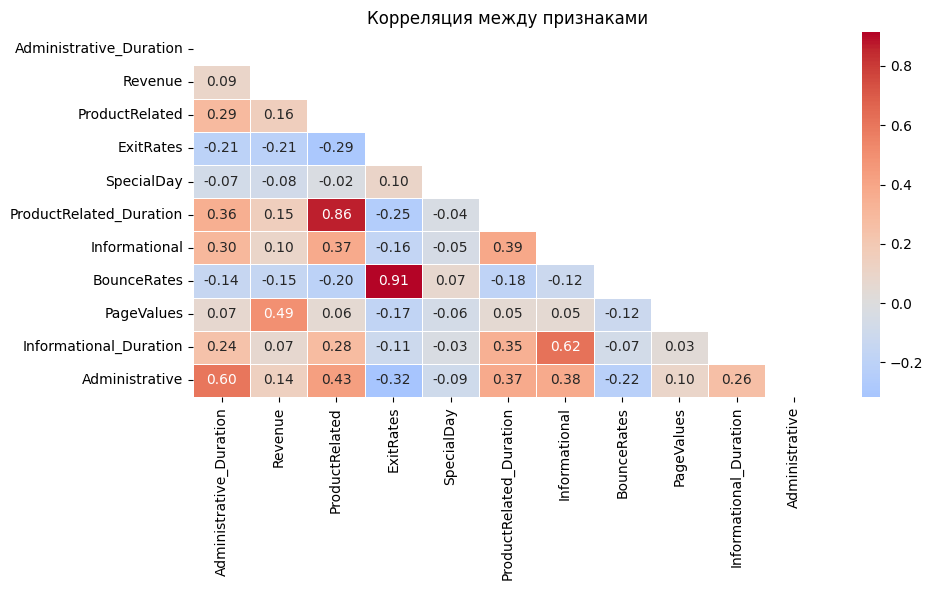

In [ ]:
plt.figure(figsize=(10, 6))
corr = df[list(quant_features.union({target_feature}))].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm', center=0, linewidths=0.5)
plt.title('Корреляция между признаками')
plt.tight_layout()
plt.show()

In [ ]:
quant_features

{'Administrative',
 'Administrative_Duration',
 'BounceRates',
 'ExitRates',
 'Informational',
 'Informational_Duration',
 'PageValues',
 'ProductRelated',
 'ProductRelated_Duration',
 'SpecialDay'}

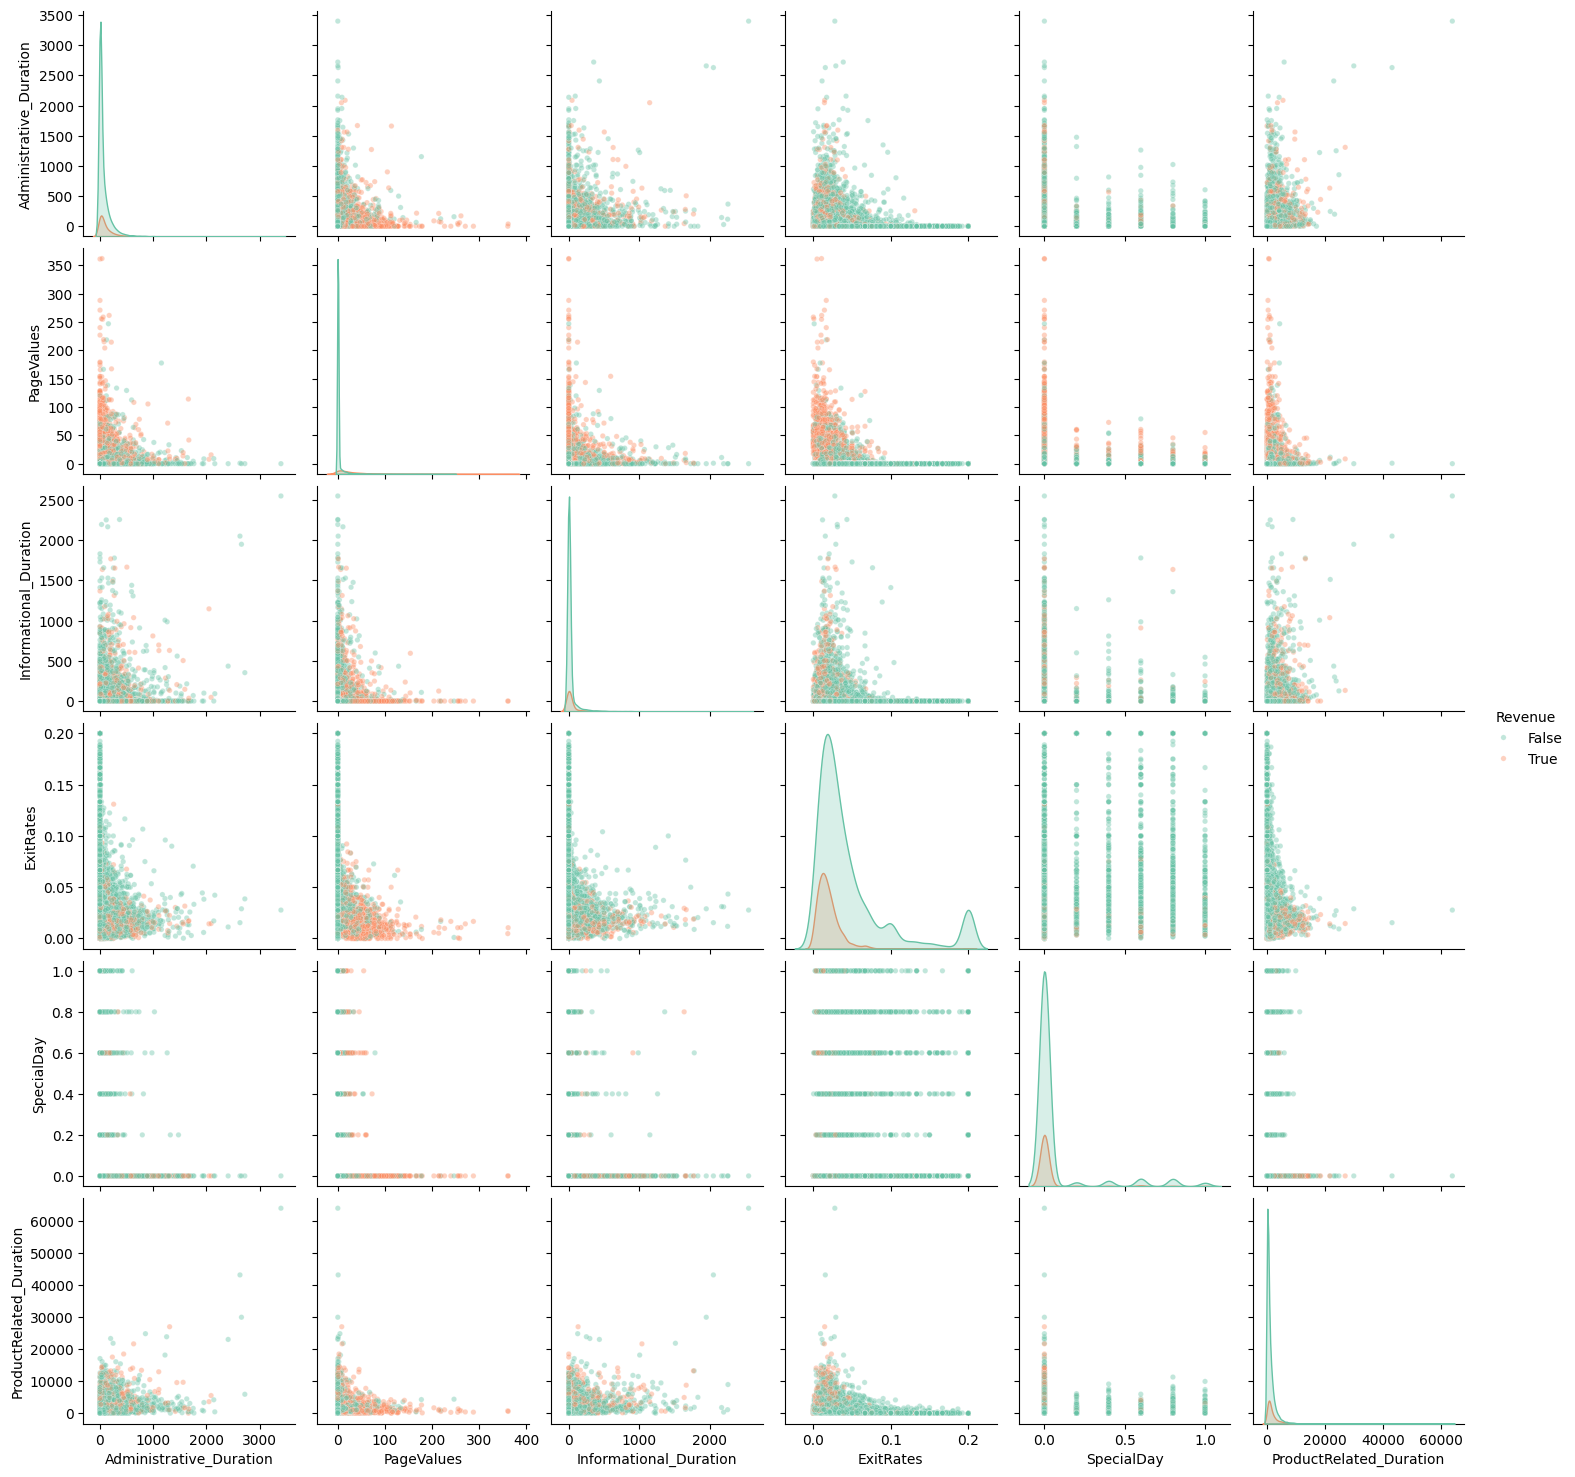

In [ ]:
col = [
    'Administrative_Duration',
    'PageValues',
    'Informational_Duration',
    'ExitRates',
    'SpecialDay',
    'ProductRelated_Duration',
     target_feature
]

sns.pairplot(
    df[col],
    hue=target_feature,
    palette='Set2',
    plot_kws={'alpha': 0.4, 's': 15}
  )

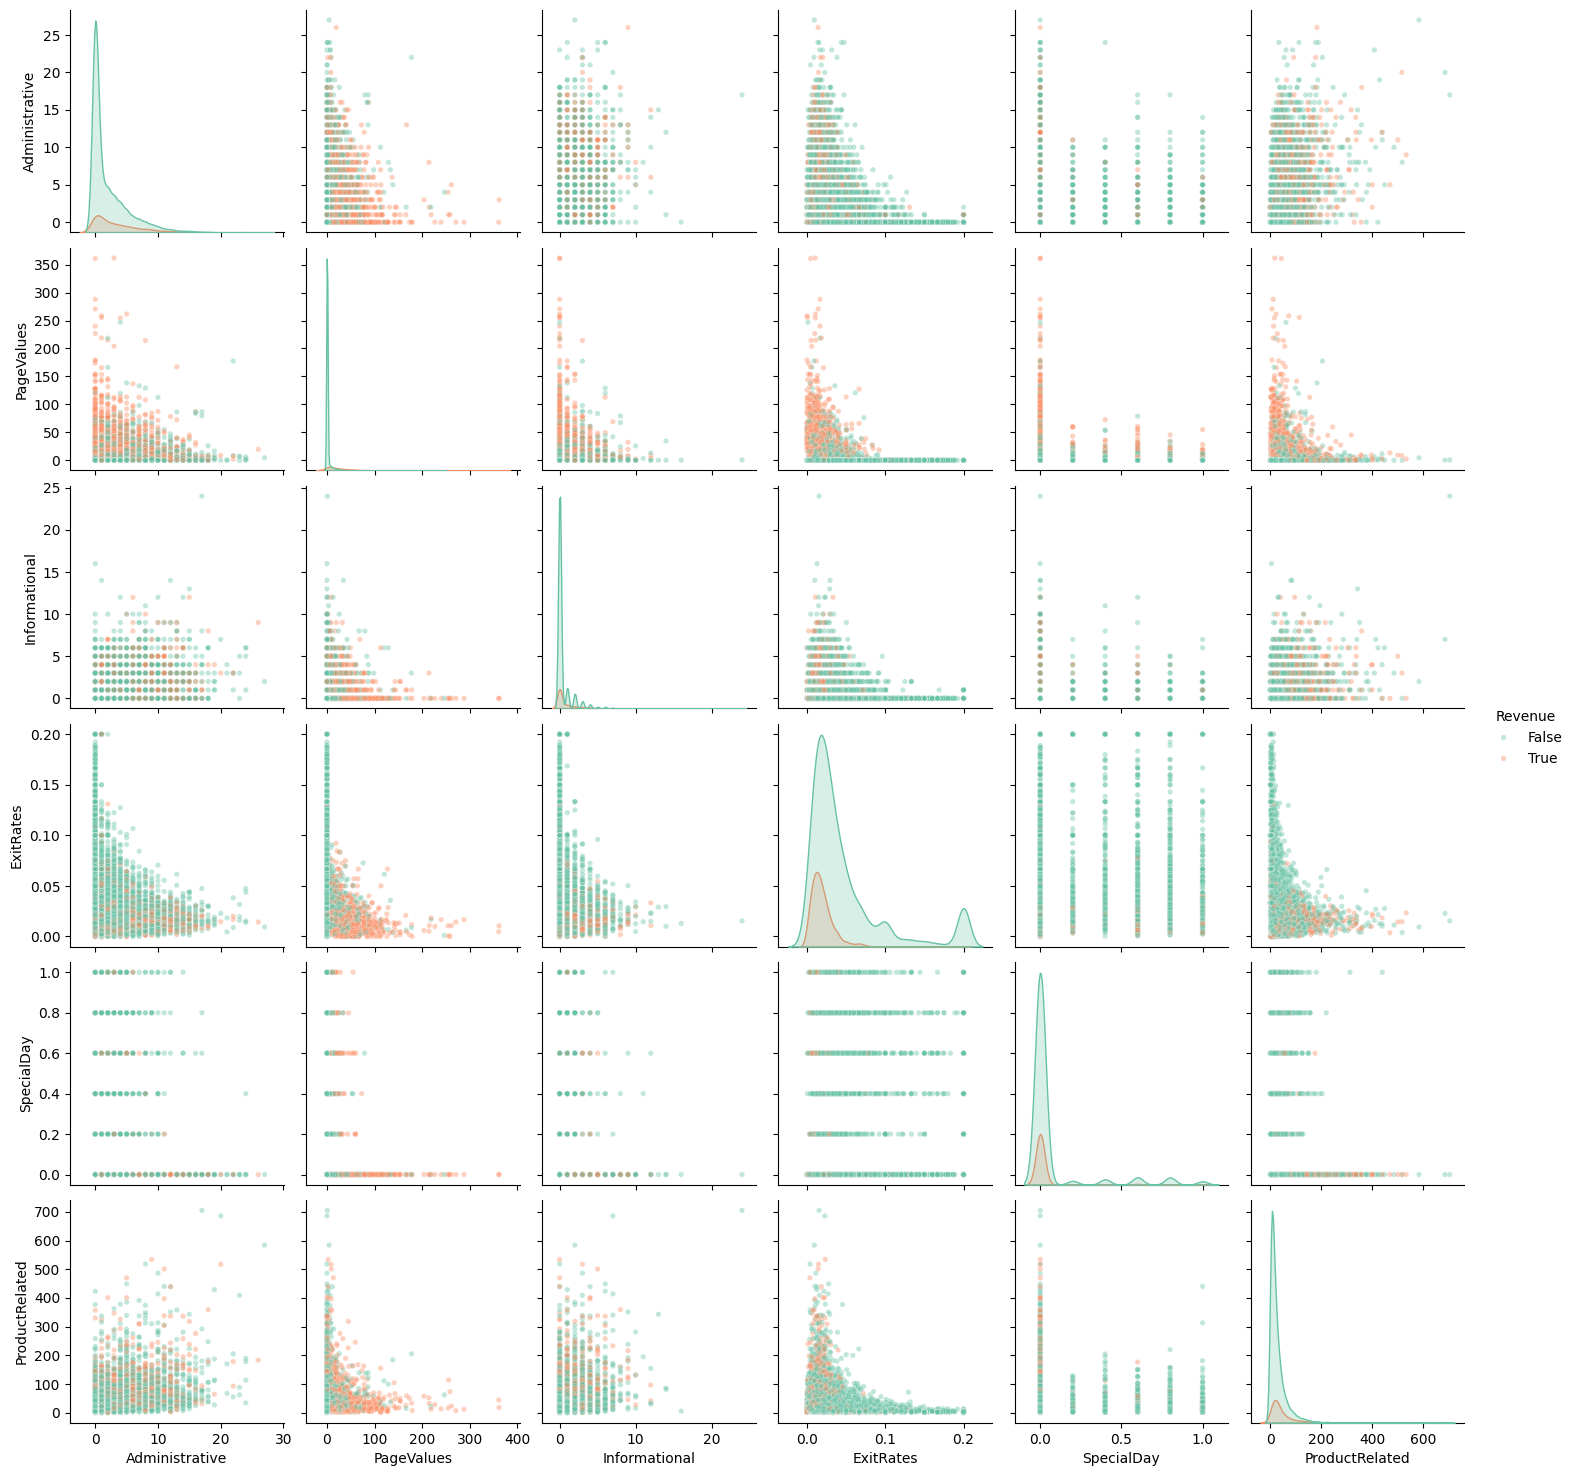

In [ ]:
col = [
    'Administrative',
    'PageValues',
    'Informational',
    'ExitRates',
    'SpecialDay',
    'ProductRelated',
     target_feature
]

sns.pairplot(
    df[col],
    hue=target_feature,
    palette='Set2',
    plot_kws={'alpha': 0.4, 's': 15}
  )

In [5]:
categ_features

{'Browser',
 'Month',
 'OperatingSystems',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend'}

In [124]:
month_to_num = {
    'Jan': 1,
    'Feb': 2,
    'Mar': 3,
    'Apr': 4,
    'May': 5,
    'June': 6,
    'Jul': 7,
    'Aug': 8,
    'Sep': 9,
    'Oct': 10,
    'Nov': 11,
    'Dec': 12
}

df['Month'] = df['Month'].map(month_to_num)

In [18]:
df.columns

Index(['Administrative', 'Administrative_Duration', 'Informational',
       'Informational_Duration', 'ProductRelated', 'ProductRelated_Duration',
       'BounceRates', 'ExitRates', 'PageValues', 'SpecialDay', 'Month',
       'OperatingSystems', 'Browser', 'Region', 'TrafficType', 'VisitorType',
       'Weekend', 'Revenue'],
      dtype='str')

In [54]:
categ_features

{'Browser',
 'Month',
 'OperatingSystems',
 'Region',
 'TrafficType',
 'VisitorType',
 'Weekend'}

In [121]:
df['VisitorType'].value_counts()

VisitorType
Returning_Visitor    10431
New_Visitor           1693
Other                   81
Name: count, dtype: int64

In [122]:
for col in (categ_features - {'Weekend'}):
    counts = df[col].value_counts()
    rare_categories = counts[counts < 10].index
    
    if pd.api.types.is_numeric_dtype(df[col]):
        df.loc[df[col].isin(rare_categories), col] = -1
    else:
        df.loc[df[col].isin(rare_categories), col] = 'Other'

In [123]:
print(df['Browser'].value_counts(), df.shape)

Browser
 2     7883
 1     2427
 4      731
 5      465
 6      174
 10     163
 8      135
 3      105
 13      56
 7       49
 12      10
-1        7
Name: count, dtype: int64 (12205, 18)


In [68]:
df['OperatingSystems'].value_counts()

OperatingSystems
 2    6541
 1    2549
 3    2530
 4     478
 8      75
 6      19
-1      13
Name: count, dtype: int64

In [70]:
df['TrafficType'].value_counts()

TrafficType
 2     3911
 1     2388
 3     2013
 4     1066
 13     728
 10     450
 6      443
 8      343
 5      260
 11     247
 20     193
 9       41
 7       40
 15      37
 19      17
 14      13
 18      10
-1        5
Name: count, dtype: int64

In [71]:
df['TrafficType'].value_counts()

TrafficType
 2     3911
 1     2388
 3     2013
 4     1066
 13     728
 10     450
 6      443
 8      343
 5      260
 11     247
 20     193
 9       41
 7       40
 15      37
 19      17
 14      13
 18      10
-1        5
Name: count, dtype: int64

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer

In [125]:
X = df.drop(target_feature, axis=1)
y = df[target_feature]

In [108]:
ct = ColumnTransformer([
    ('visitor_encoder', OneHotEncoder(), ['VisitorType'])
], remainder='passthrough')


In [127]:
X_encoded = ct.fit_transform(X)

In [102]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold

In [128]:
X_train, X_test, y_train, y_test =  train_test_split(X_encoded, y, test_size=0.2, random_state=SEED, stratify=y)

In [129]:
tree = DecisionTreeClassifier(random_state=42)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

scores = cross_val_score(tree, X_train, y_train, cv=cv, scoring='f1')

print(f"Средний F1: {scores.mean():.3f} (+/- {scores.std():.3f})")

Средний F1: 0.554 (+/- 0.011)
